# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [1]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd

## Dataset


In [2]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")


In [3]:
loan_data.head(30)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


## EDA
Uncomment to see desired output. Add more analysis if you like

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
           loan_id  no_of_dependents    education  self_employed  \
count  4269.000000       4269.000000  4269.000000    4269.000000   
mean   2135.000000          2.498712     0.502225       0.503631   
std    1232.498479          1.695910     0.500054       0.500045   
min       1.000000          0.000000     0.000000       0.000000   
25%    1068.000000          1.000000     0.000000       0.000000   
50%    2135.000000          3.000000     1.000000       1.000000   
75%    3202.000000          4.000000     1.000000       1.000000   
max    4269.000000          5.000000     1.000000       1.000000   

       income_annum   loan_amount    loan_term  cibil_score  \
count  4.269000e+03  4.269000e+03  4269.

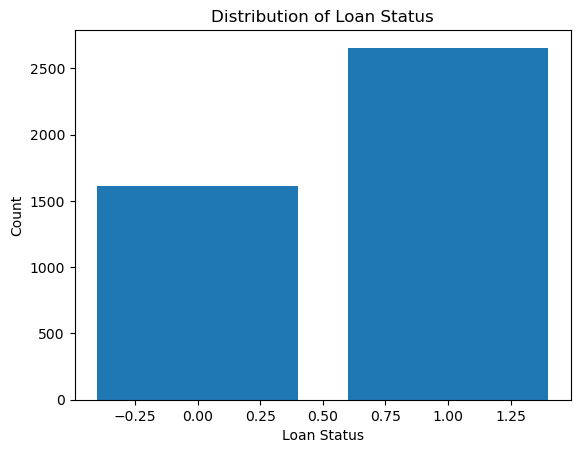

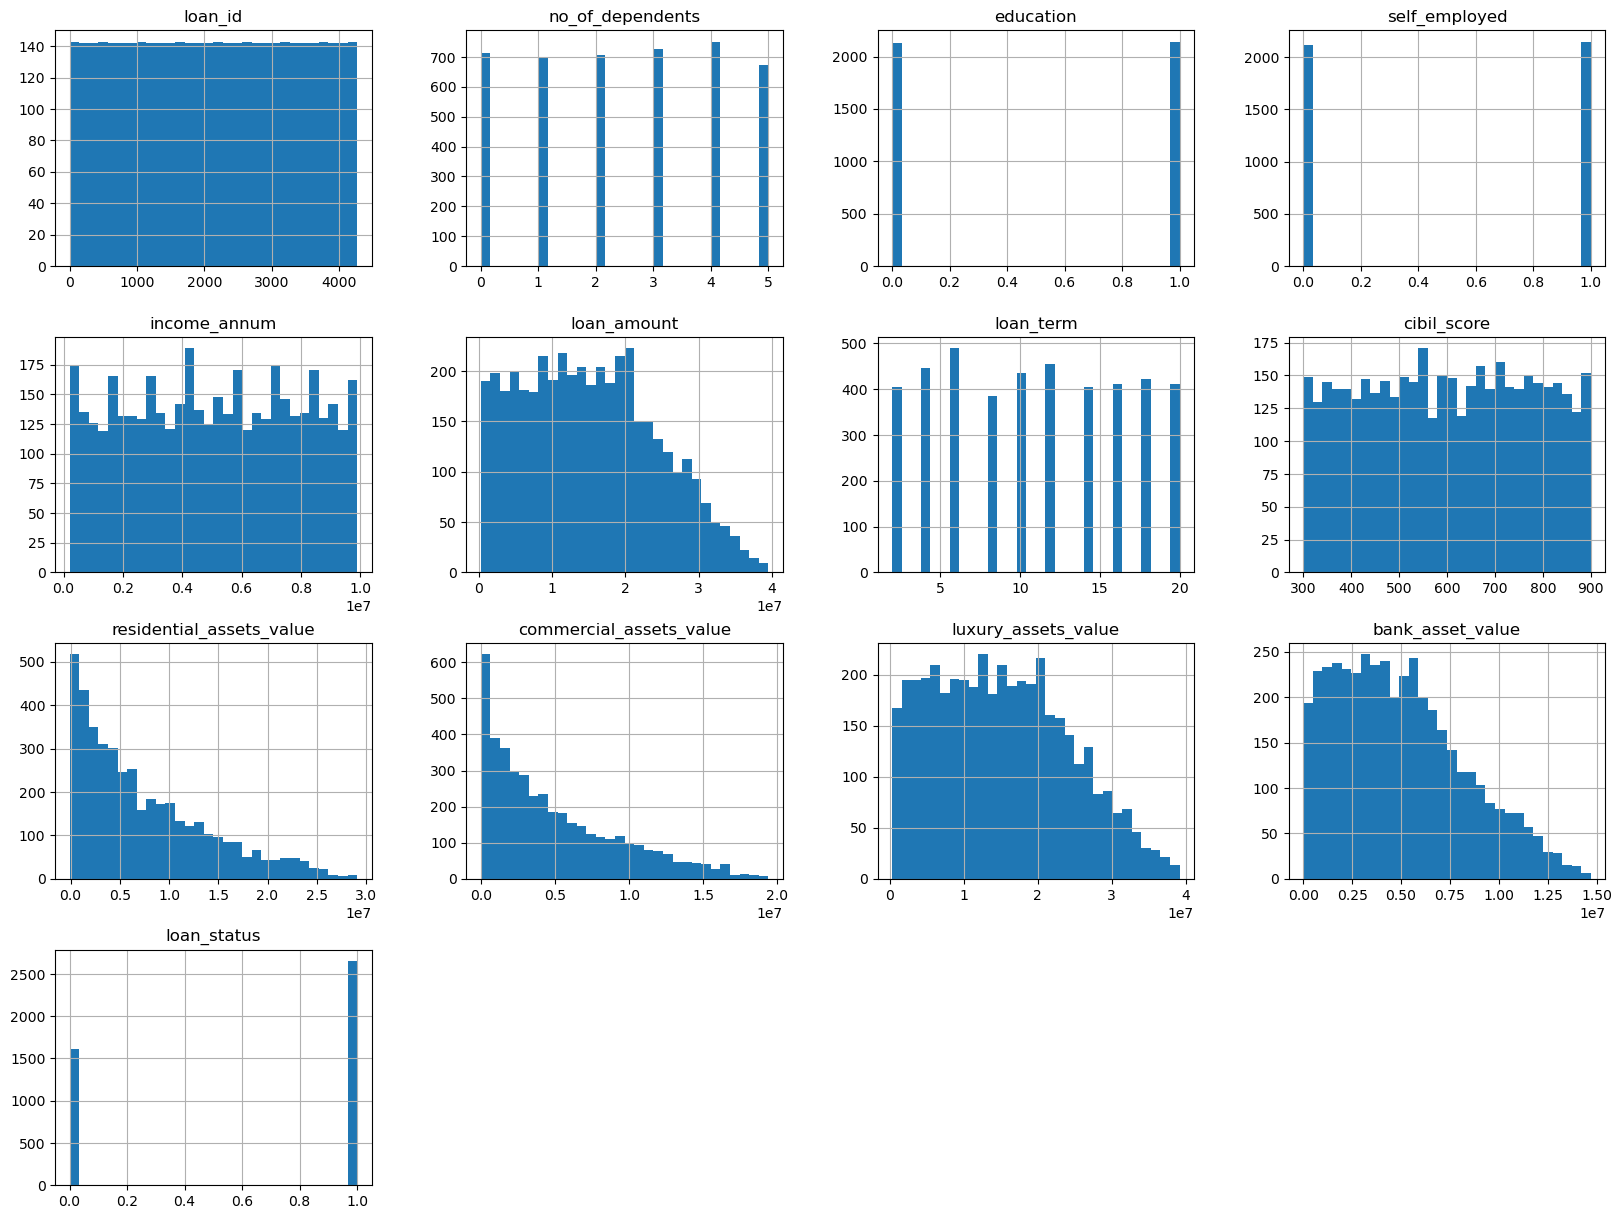

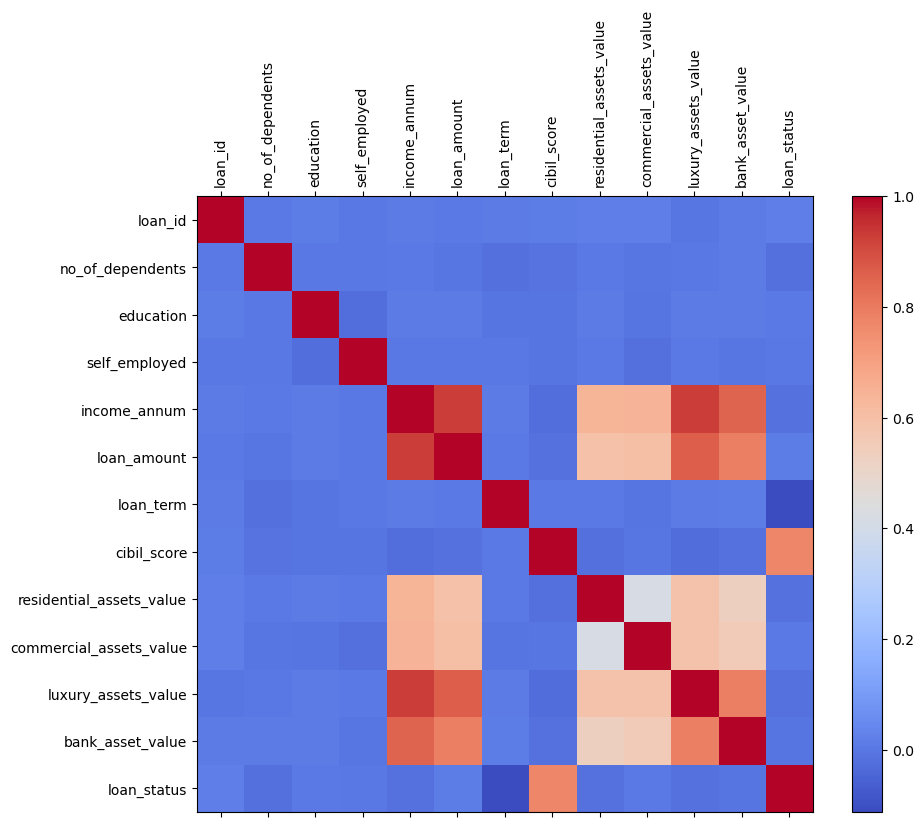

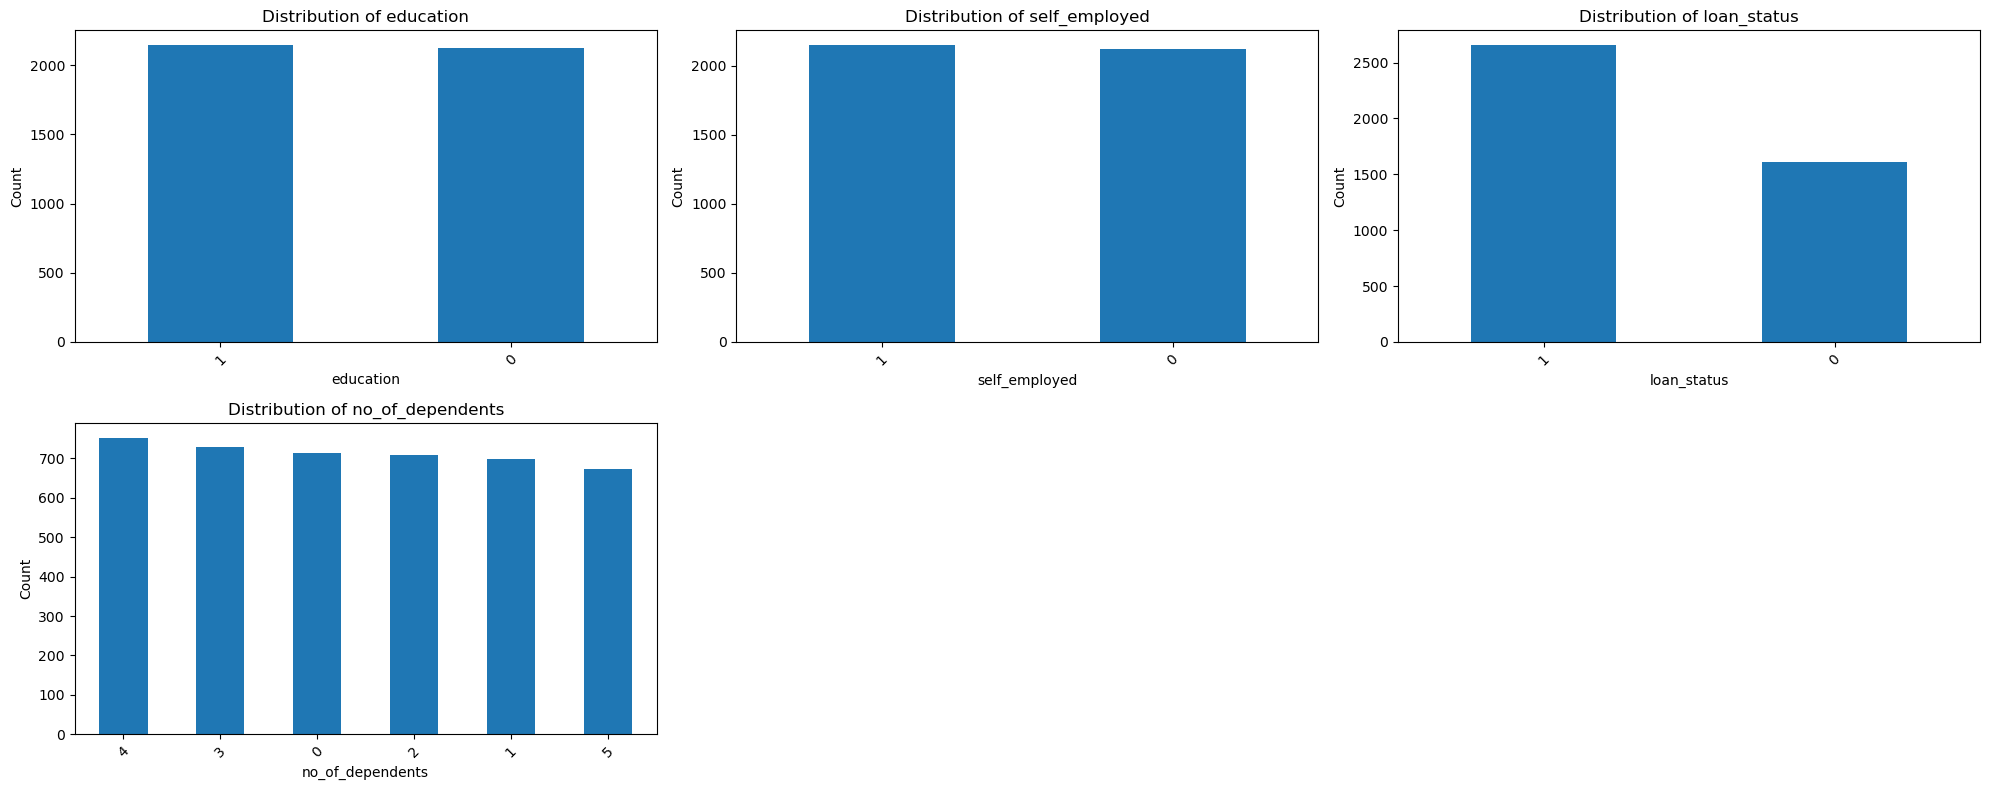

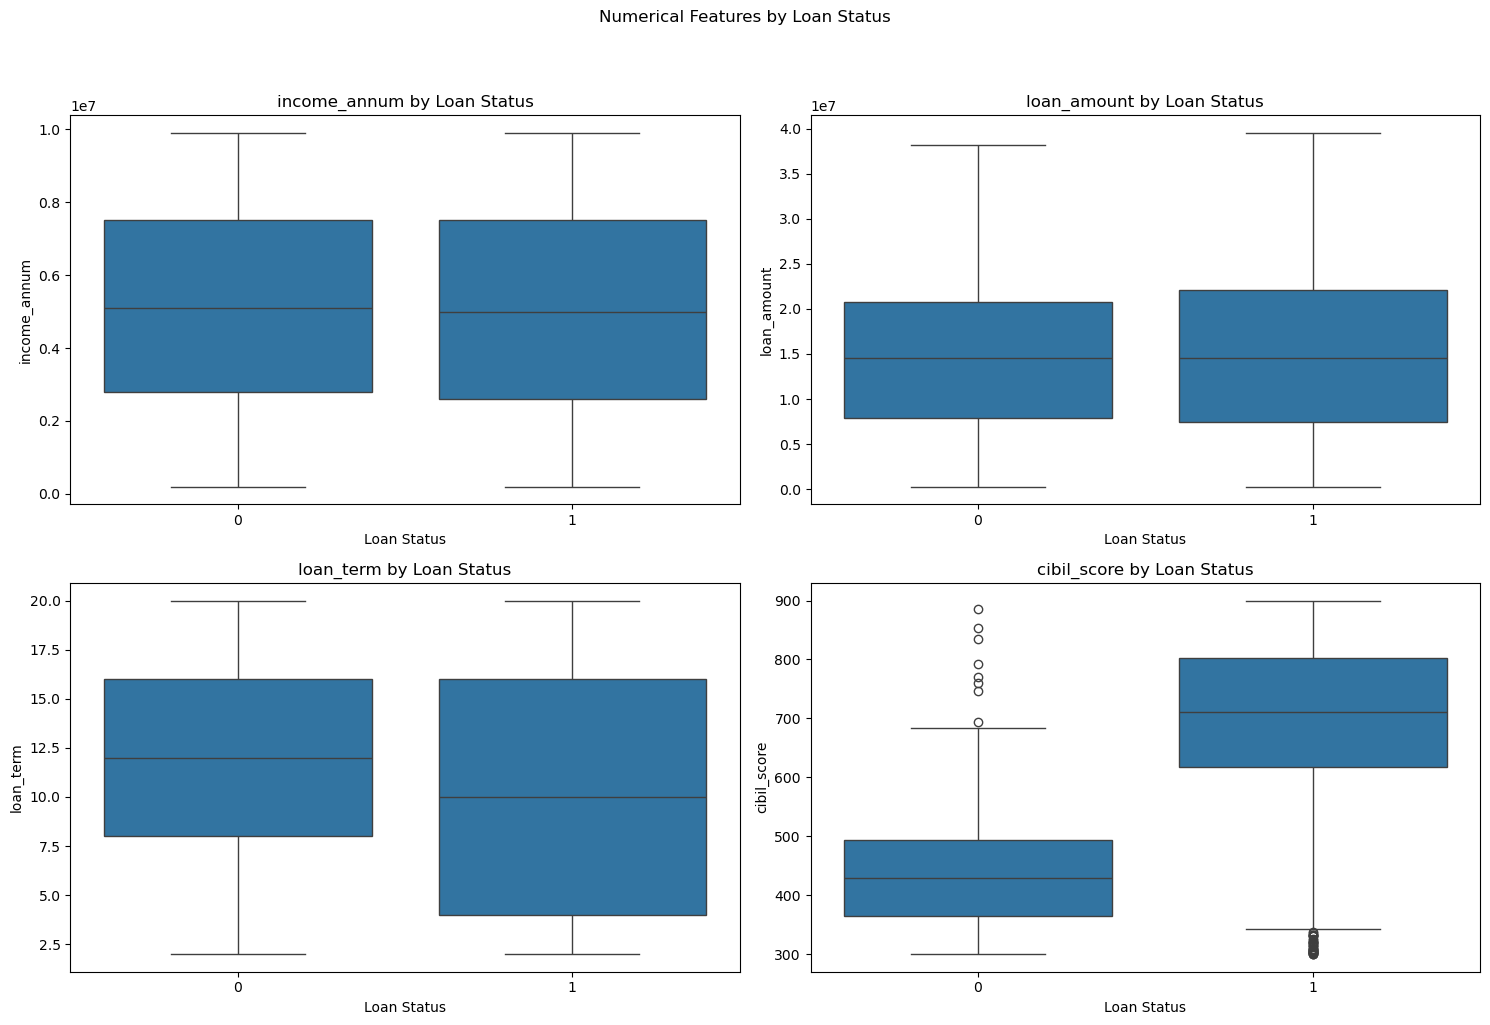


--- Loan Status by Categorical Features (Proportions) ---


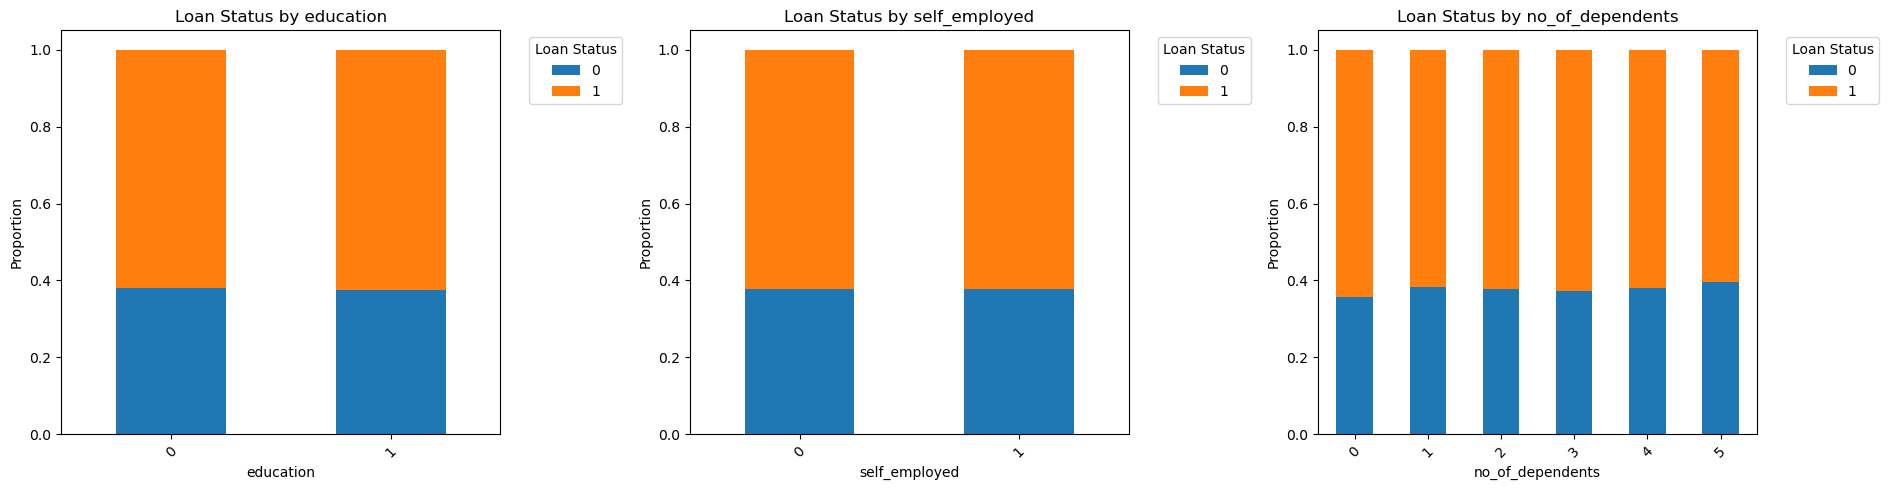

In [4]:

import matplotlib.pyplot as plt
import numpy as np

# Robust encoding of categorical fields (tolerant to case/whitespace/variants)
if loan_data['education'].dtype == 'O':
    loan_data['education'] = loan_data['education'].astype(str).str.strip().str.lower().map({
        'graduate': 1,
        'not graduate': 0,
        'notgraduate': 0
    })
if loan_data['self_employed'].dtype == 'O':
    loan_data['self_employed'] = loan_data['self_employed'].astype(str).str.strip().str.lower().map({
        'yes': 1, 'y': 1, 'true': 1, '1': 1,
        'no': 0, 'n': 0, 'false': 0, '0': 0
    })
if loan_data['loan_status'].dtype == 'O':
    loan_data['loan_status'] = loan_data['loan_status'].astype(str).str.strip().str.lower().map({
        'y': 1, 'yes': 1, 'approved': 1, '1': 1, 'true': 1,
        'n': 0, 'no': 0, 'rejected': 0, '0': 0, 'false': 0
    })

# ------ Display basic information ------
print(loan_data.columns)
print(loan_data.describe())

# ------ Check for missing values ------
print(loan_data.isnull().sum())

# ------ Visualize the distribution of loan status ------
loan_status_counts = loan_data['loan_status'].value_counts()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# ------ Visualize the distribution of numerical features ------ 
loan_data.hist(bins=30, figsize=(20, 15))

# ------ Correlation matrix ------
corr_matrix = loan_data.select_dtypes(include='number').corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# ----- MORE (Encouraged but not required) ------

# ------ Visualize distributions of categorical features ------
candidate_cats = ['education', 'self_employed', 'loan_status', 'no_of_dependents']
categorical_cols_dist = [col for col in candidate_cats if col in loan_data.columns]
# Filter out columns with empty value_counts (all NaN)
categorical_cols_dist = [col for col in categorical_cols_dist if loan_data[col].notna().any() and loan_data[col].value_counts().size > 0]
num_plots = len(categorical_cols_dist)
if num_plots > 0:
    ncols = 3
    nrows = (num_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    # Ensure axes is a flat list
    if hasattr(axes, 'flatten'):
        axes = axes.flatten()
    else:
        axes = [axes]
    for i, col in enumerate(categorical_cols_dist):
        loan_data[col].value_counts().plot(kind='bar', ax=axes[i], title=f'Distribution of {col}')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)
    # Remove any unused axes
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with data to plot.")

# ------ Visualize numerical features against loan status (Box Plots) ------
# Skip entirely if loan_status is missing/constant
import seaborn as sns
if 'loan_status' not in loan_data.columns or loan_data['loan_status'].dropna().nunique() < 2:
    print('Skipping numerical vs loan_status plots: loan_status missing or single class.')
else:
    candidate_num_cols = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score']
    candidate_num_cols = [col for col in candidate_num_cols if col in loan_data.columns]
    valid_box_cols = []
    for col in candidate_num_cols:
        df_tmp = loan_data[['loan_status', col]].dropna()
        if df_tmp.shape[0] > 0 and df_tmp[col].notna().any():
            valid_box_cols.append(col)

    num_plots = len(valid_box_cols)
    if num_plots > 0:
        ncols = 2
        nrows = (num_plots + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
        if hasattr(axes, 'flatten'):
            axes = axes.flatten()
        else:
            axes = [axes]
        for i, col in enumerate(valid_box_cols):
            sns.boxplot(data=loan_data, x='loan_status', y=col, ax=axes[i])
            axes[i].set_title(f'{col} by Loan Status')
            axes[i].set_xlabel('Loan Status')
            axes[i].set_ylabel(col)
        for j in range(num_plots, len(axes)):
            fig.delaxes(axes[j])
        plt.suptitle('Numerical Features by Loan Status', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()
    else:
        print('No valid numerical columns to plot by loan_status.')

# ------ Visualize categorical features against loan status (Proportions) ------
print("\n--- Loan Status by Categorical Features (Proportions) ---")
# Skip if loan_status missing/constant
if 'loan_status' not in loan_data.columns or loan_data['loan_status'].dropna().nunique() < 2:
    print('Skipping categorical vs loan_status: loan_status missing or single class.')
else:
    candidate_cats = ['education', 'self_employed', 'no_of_dependents']
    categorical_for_status_analysis = [col for col in candidate_cats if col in loan_data.columns]

    # Build dynamic grid
    num_plots = len(categorical_for_status_analysis)
    if num_plots > 0:
        ncols = 3
        nrows = (num_plots + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
        if hasattr(axes, 'flatten'):
            axes = axes.flatten()
        else:
            axes = [axes]
        plotted = 0
        for i, col in enumerate(categorical_for_status_analysis):
            ct = pd.crosstab(loan_data[col], loan_data['loan_status'])
            if ct.empty:
                continue
            prop = ct.div(ct.sum(1).replace(0, np.nan), axis=0).astype(float)
            if prop.select_dtypes(include='number').size == 0 or np.all(~np.isfinite(prop.values)):
                continue
            prop.plot(kind='bar', stacked=True, ax=axes[plotted], title=f'Loan Status by {col}')
            axes[plotted].set_ylabel('Proportion')
            axes[plotted].set_xlabel(col)
            axes[plotted].tick_params(axis='x', rotation=45)
            axes[plotted].legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')
            plotted += 1
        for j in range(plotted, len(axes)):
            fig.delaxes(axes[j])
        if plotted == 0:
            plt.close(fig)
            print('No categorical proportion plots could be generated (no numeric data).')
        else:
            plt.tight_layout(rect=[0, 0, 0.95, 1])
            plt.show()
    else:
        print('No categorical columns found for status analysis.')


## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [5]:
# Modeling setup: preprocessing, data split, and model registry (no training here)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Optional imports with graceful fallback
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import torch
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

# Prepare features/target
TARGET_COL = 'loan_status'
feature_df = loan_data.copy()
feature_df = feature_df.drop(columns=['loan_id'], errors='ignore')

# Clean target: robust mapping already applied in EDA; drop missing/invalid
feature_df = feature_df.dropna(subset=[TARGET_COL])
feature_df = feature_df[feature_df[TARGET_COL].isin([0, 1])]
feature_df[TARGET_COL] = feature_df[TARGET_COL].astype(int)

# Features: keep numeric only, drop all-NaN cols
X = feature_df.drop(columns=[TARGET_COL]).select_dtypes(include='number').dropna(axis=1, how='all')
y = feature_df[TARGET_COL]

# If any remaining rows have all-NaN across X (after selection), drop them
valid_rows = X.notna().any(axis=1)
X = X[valid_rows]
y = y.loc[valid_rows]

# Numeric-only preprocessing
numeric_features = X.columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='drop'
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Helper: wrap LinearRegression for classification-like API
class LinearRegressionClassifier:
    def __init__(self):
        self.reg = LinearRegression()
    def fit(self, X, y):
        self.reg.fit(X, y)
        return self
    def predict(self, X):
        p = np.clip(self.reg.predict(X), 0.0, 1.0)
        return (p >= 0.5).astype(int)
    def predict_proba(self, X):
        p = np.clip(self.reg.predict(X), 0.0, 1.0)
        return np.vstack([1 - p, p]).T

# Registry of models to train in the next cell
models = {
    'LogisticRegression': Pipeline([
        ('prep', preprocess),
        ('clf', LogisticRegression(max_iter=500))
    ]),
    'LinearRegressionBaseline': Pipeline([
        ('prep', preprocess),
        ('clf', LinearRegressionClassifier())
    ]),
    'GaussianNB': Pipeline([
        ('prep', preprocess),
        ('clf', GaussianNB())
    ]),
    'SVM_RBF': Pipeline([
        ('prep', preprocess),
        ('clf', SVC(kernel='rbf', probability=True))
    ]),
    'KNN_15': Pipeline([
        ('prep', preprocess),
        ('clf', KNeighborsClassifier(n_neighbors=15))
    ]),
    'PCA+LogReg': Pipeline([
        ('prep', preprocess),
        ('pca', PCA(n_components=10)),
        ('clf', LogisticRegression(max_iter=500))
    ]),
}

if HAS_XGB:
    models['XGBoost'] = Pipeline([
        ('prep', preprocess),
        ('clf', XGBClassifier(
            n_estimators=300,
            learning_rate=0.08,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric='logloss'
        ))
    ])

print(f"Models ready: {list(models.keys())}")
print("Proceed to the next cell to train, evaluate, and plot.")


Models ready: ['LogisticRegression', 'LinearRegressionBaseline', 'GaussianNB', 'SVM_RBF', 'KNN_15', 'PCA+LogReg', 'XGBoost']
Proceed to the next cell to train, evaluate, and plot.


## Model Training and Evaluation and Comparison

/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


                      model  accuracy  precision    recall        f1   roc_auc
6                   XGBoost  0.981265   0.983114  0.986817  0.984962  0.998146
3                   SVM_RBF  0.944965   0.958333  0.952919  0.955619  0.986462
2                GaussianNB  0.948478   0.958569  0.958569  0.958569  0.976544
1  LinearRegressionBaseline  0.928571   0.953668  0.930320  0.941849  0.973693
0        LogisticRegression  0.913349   0.920810  0.941620  0.931099  0.972550
5                PCA+LogReg  0.918033   0.922936  0.947269  0.934944  0.971687
4                    KNN_15  0.907494   0.923221  0.928437  0.925822  0.970276


/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/var/folders/t_/zrszv1g95pg_t0_0zg0y_3l00000gn/T/ipykernel_71601/428572756.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


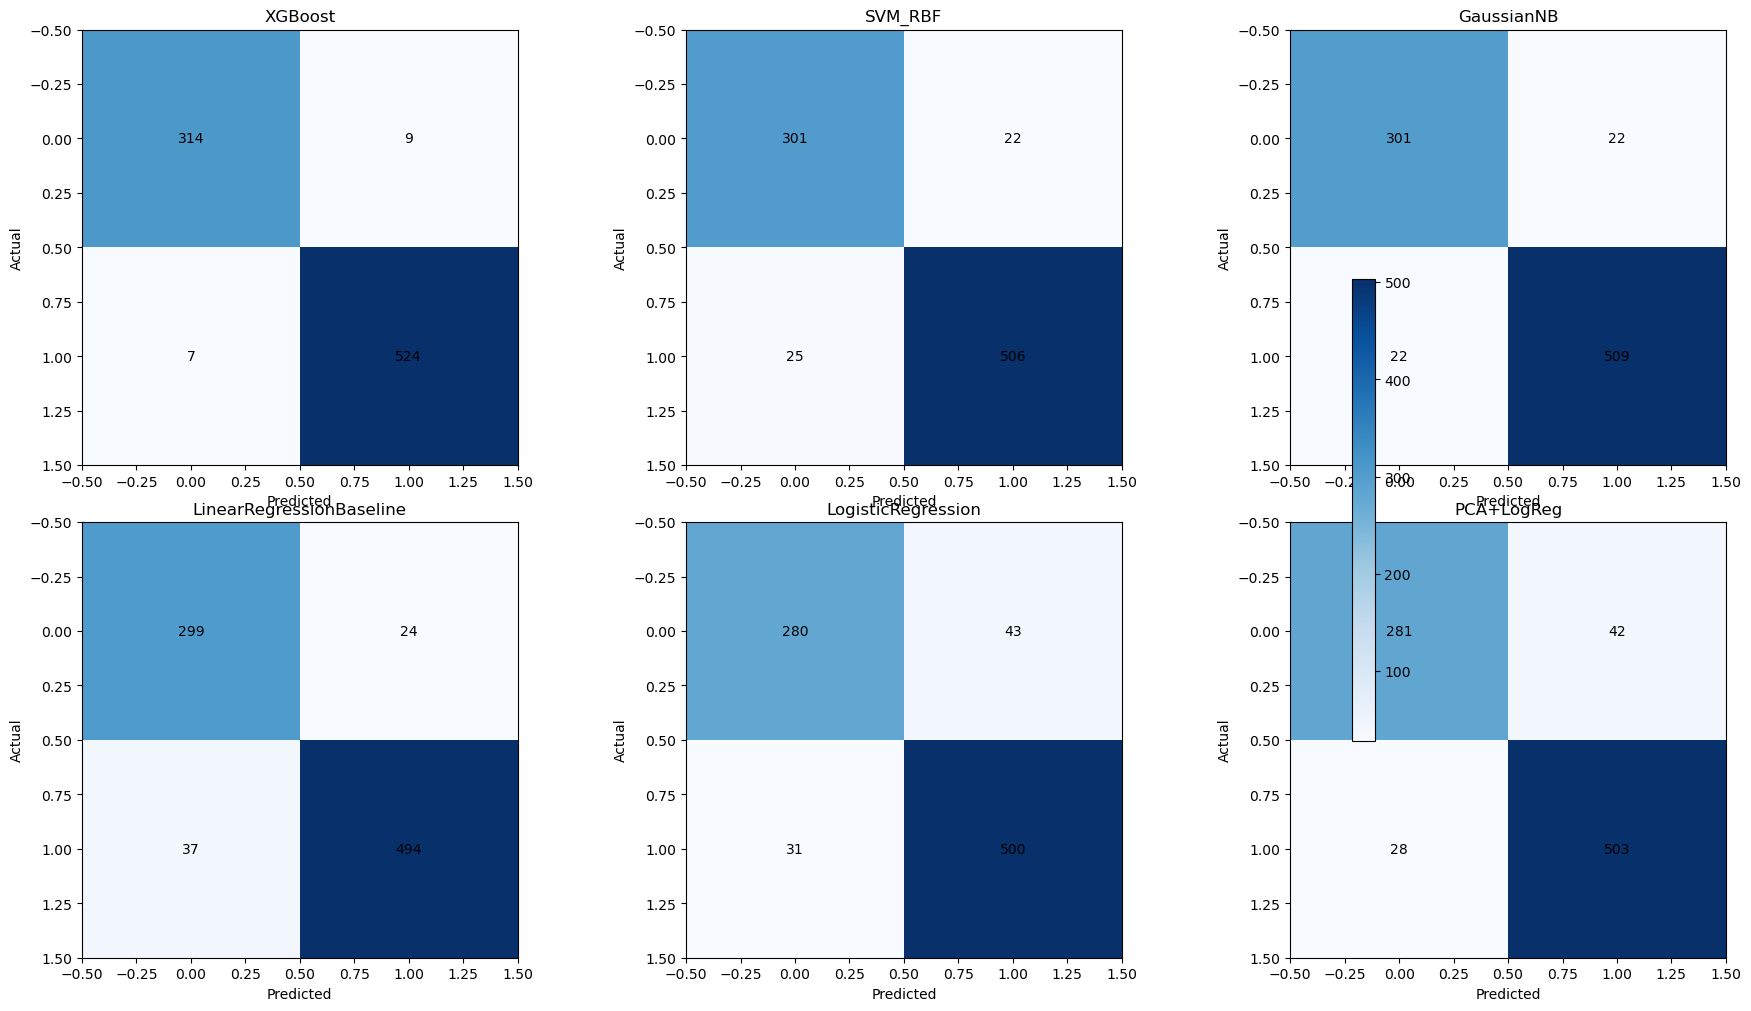

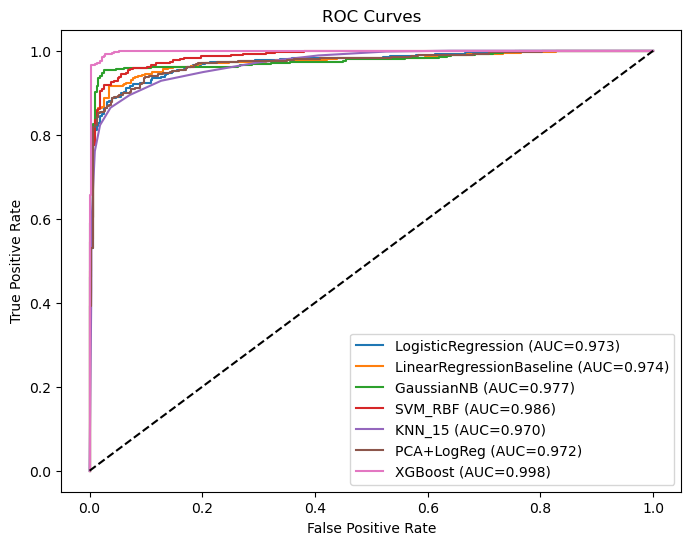

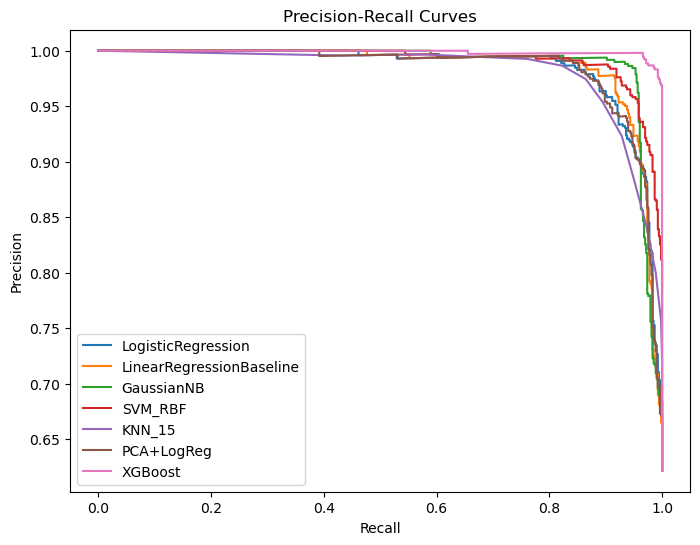

/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Train vs Test Accuracy:
                      model  train_acc  test_acc
6                   XGBoost   1.000000  0.981265
2                GaussianNB   0.930015  0.948478
3                   SVM_RBF   0.955783  0.944965
1  LinearRegressionBaseline   0.923865  0.928571
5                PCA+LogReg   0.917130  0.918033
0        LogisticRegression   0.918302  0.913349
4                    KNN_15   0.927086  0.907494


/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


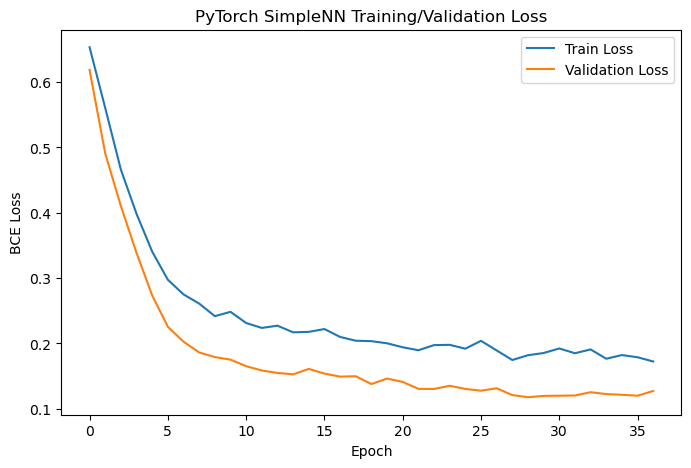


PyTorch SimpleNN test metrics:
Accuracy: 0.9531615925058547
Precision: 0.9694072657743786
Recall: 0.9548022598870056
F1: 0.9620493358633776
ROC AUC: 0.9919831149825378


,model,accuracy,precision,recall,f1,roc_auc
6,XGBoost,0.981265,0.983114,0.986817,0.984962,0.998146
3,SVM_RBF,0.944965,0.958333,0.952919,0.955619,0.986462
2,GaussianNB,0.948478,0.958569,0.958569,0.958569,0.976544
1,LinearRegressionBaseline,0.928571,0.953668,0.930320,0.941849,0.973693
0,LogisticRegression,0.913349,0.920810,0.941620,0.931099,0.972550
5,PCA+LogReg,0.918033,0.922936,0.947269,0.934944,0.971687
4,KNN_15,0.907494,0.923221,0.928437,0.925822,0.970276


In [6]:
# Train, evaluate, compare models, and plot diagnostics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

results = []
probas_dict = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Probas for AUC/ROC if supported
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        try:
            # SVM decision function fallback
            if hasattr(model, 'decision_function'):
                scores = model.decision_function(X_test)
                y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
            else:
                y_proba = None
        except Exception:
            y_proba = None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    results.append({
        'model': name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'roc_auc': auc
    })
    if y_proba is not None:
        probas_dict[name] = y_proba

results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)
print(results_df)

# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, row in enumerate(results_df.itertuples()):
    if i >= len(axes):
        break
    name = row.model
    y_pred = models[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[i]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for (j, k), val in np.ndenumerate(cm):
        ax.text(k, j, int(val), ha='center', va='center')
fig.colorbar(im, ax=axes.tolist(), shrink=0.6)
plt.tight_layout()
plt.show()

# ROC curves
if len(probas_dict) > 0:
    plt.figure(figsize=(8, 6))
    for name, y_proba in probas_dict.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()

# PR curves
if len(probas_dict) > 0:
    plt.figure(figsize=(8, 6))
    for name, y_proba in probas_dict.items():
        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(rec, prec, label=name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves')
    plt.legend()
    plt.show()

# Overfit check: train vs test accuracy
overfit = []
for name, model in models.items():
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)
    overfit.append({
        'model': name,
        'train_acc': accuracy_score(y_train, y_pred_tr),
        'test_acc': accuracy_score(y_test, y_pred_te)
    })
overfit_df = pd.DataFrame(overfit).sort_values(by='test_acc', ascending=False)
print('\nTrain vs Test Accuracy:')
print(overfit_df)

# PyTorch model with loss curves (optional)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

if HAS_TORCH:
    # Use same preprocess to build tensors
    X_proc_tr = preprocess.fit_transform(X_train)
    X_proc_te = preprocess.transform(X_test)
    y_tr = y_train.values.astype(np.float32)
    y_te = y_test.values.astype(np.float32)

    input_dim = X_proc_tr.shape[1]
    class SimpleNN(nn.Module):
        def __init__(self, in_features):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_features, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(128, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(32, 1)
            )
        def forward(self, x):
            return self.net(x)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_nn = SimpleNN(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model_nn.parameters(), lr=3e-4, weight_decay=1e-4)
    from torch.optim.lr_scheduler import ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=False)

    Xtr_tensor = torch.tensor(X_proc_tr.toarray() if hasattr(X_proc_tr, 'toarray') else X_proc_tr, dtype=torch.float32)
    Xte_tensor = torch.tensor(X_proc_te.toarray() if hasattr(X_proc_te, 'toarray') else X_proc_te, dtype=torch.float32)
    ytr_tensor = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    yte_tensor = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

    ds_train = TensorDataset(Xtr_tensor, ytr_tensor)
    dl_train = DataLoader(ds_train, batch_size=128, shuffle=True)

    train_losses = []
    val_losses = []
    best_val = float('inf')
    best_state = None
    no_improve = 0
    epochs = 50
    patience = 8
    for epoch in range(epochs):
        model_nn.train()
        running = 0.0
        for xb, yb in dl_train:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model_nn(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_losses.append(running / len(ds_train))

        model_nn.eval()
        with torch.no_grad():
            logits_val = model_nn(Xte_tensor.to(device))
            val_loss = criterion(logits_val, yte_tensor.to(device)).item()
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_nn.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    if best_state is not None:
        model_nn.load_state_dict(best_state)

    # Plot train/test (val) loss curves
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.title('PyTorch SimpleNN Training/Validation Loss')
    plt.legend()
    plt.show()

    # Final PyTorch metrics
    with torch.no_grad():
        logits = model_nn(Xte_tensor.to(device)).squeeze(1).cpu().numpy()
        probs = 1 / (1 + np.exp(-logits))
        preds = (probs >= 0.5).astype(int)
        print('\nPyTorch SimpleNN test metrics:')
        print('Accuracy:', accuracy_score(y_test, preds))
        print('Precision:', precision_score(y_test, preds, zero_division=0))
        print('Recall:', recall_score(y_test, preds, zero_division=0))
        print('F1:', f1_score(y_test, preds, zero_division=0))
        print('ROC AUC:', roc_auc_score(y_test, probs))

# Show top results table last
results_df


## Model Optimization and Testing

/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "/opt/homebrew/Caskroom/miniforge/base/envs/loan_models_env/lib/python3.10/site-pa

Optimization summary (sorted by test ROC AUC):
                      model  cv_roc_auc_mean  cv_roc_auc_std  test_accuracy  \
6                   XGBoost         0.998161        0.000829       0.981265   
3                   SVM_RBF         0.984649        0.004377       0.949649   
2                GaussianNB         0.964339        0.007543       0.948478   
4                    KNN_15         0.968935        0.005755       0.921546   
1  LinearRegressionBaseline              NaN             NaN       0.928571   
0        LogisticRegression         0.966313        0.008261       0.913349   
5                PCA+LogReg         0.964673        0.008740       0.919204   

   test_precision  test_recall   test_f1  test_roc_auc     brier  \
6        0.986767     0.983051  0.984906      0.998811  0.012636   
3        0.958647     0.960452  0.959548      0.990654  0.036075   
2        0.958569     0.958569  0.958569      0.976544  0.050035   
4        0.936090     0.937853  0.936971      0.

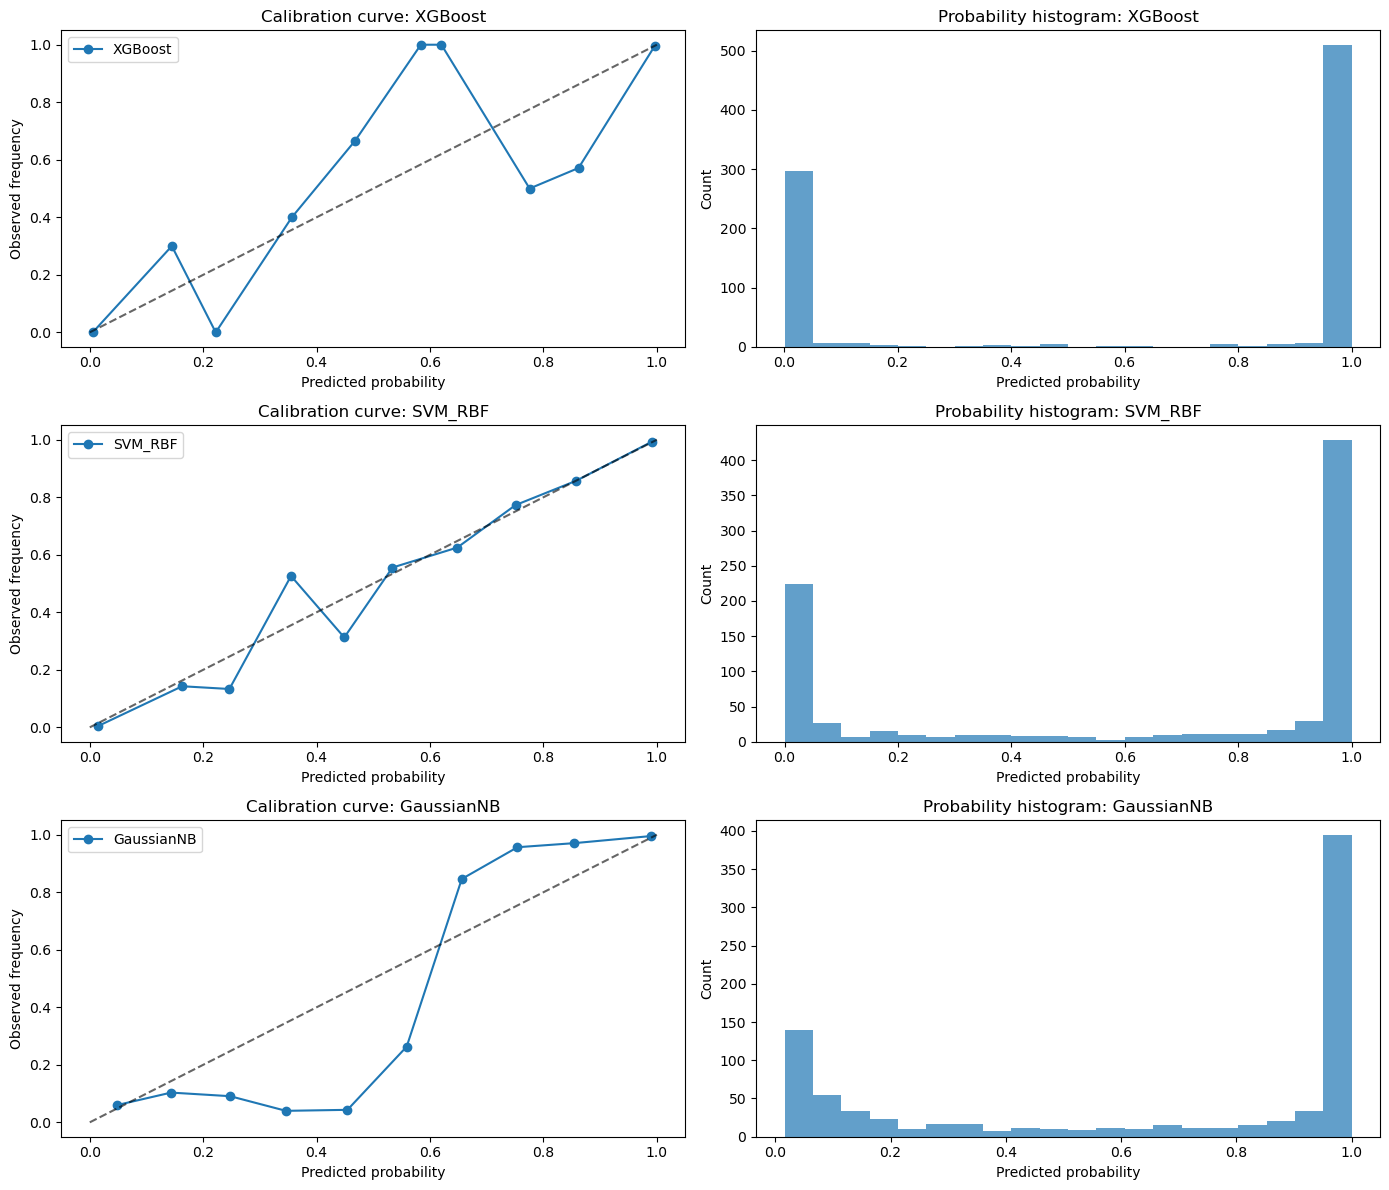

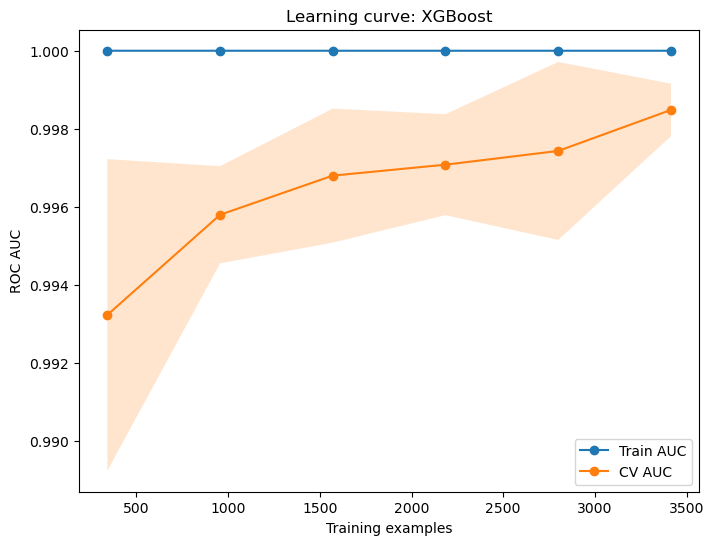

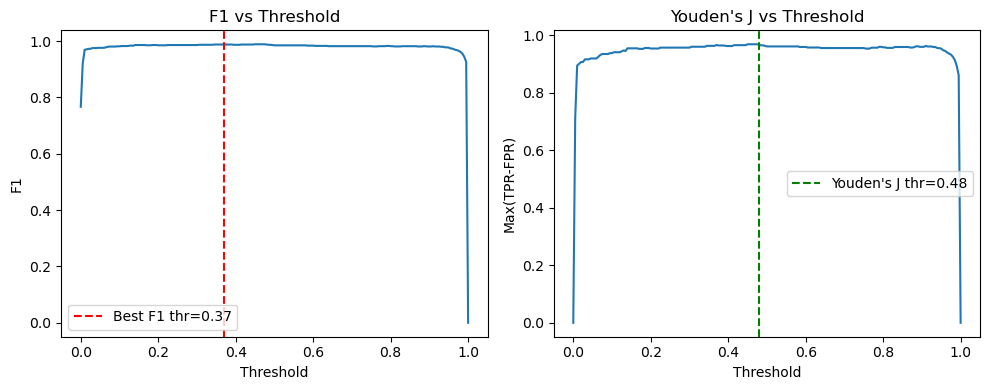


Metrics at best_F1 threshold (0.370) for XGBoost:
Accuracy: 0.9859484777517564
Precision: 0.9832402234636871
Recall: 0.9943502824858758
F1: 0.9887640449438202

Metrics at best_YoudenJ threshold (0.480) for XGBoost:
Accuracy: 0.9859484777517564
Precision: 0.9868667917448405
Recall: 0.9905838041431262
F1: 0.9887218045112782


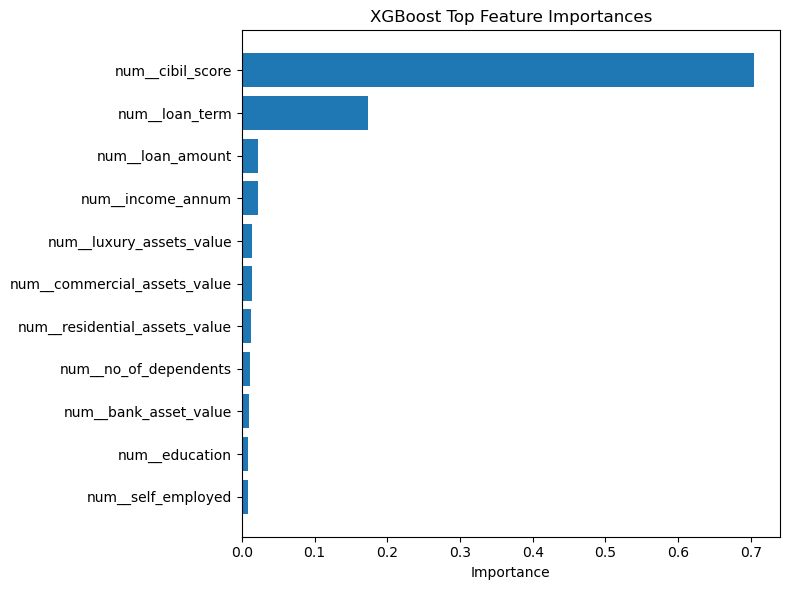

,model,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,brier,best_params
6,XGBoost,0.998161,0.000829,0.981265,0.986767,0.983051,0.984906,0.998811,0.012636,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
3,SVM_RBF,0.984649,0.004377,0.949649,0.958647,0.960452,0.959548,0.990654,0.036075,"{'clf__C': 10.0, 'clf__gamma': 'scale'}"
2,GaussianNB,0.964339,0.007543,0.948478,0.958569,0.958569,0.958569,0.976544,0.050035,{}
4,KNN_15,0.968935,0.005755,0.921546,0.936090,0.937853,0.936971,0.974089,0.075873,"{'clf__n_neighbors': 25, 'clf__weights': 'dist..."
1,LinearRegressionBaseline,NaN,NaN,0.928571,0.953668,0.930320,0.941849,0.973693,0.081265,{}
0,LogisticRegression,0.966313,0.008261,0.913349,0.920810,0.941620,0.931099,0.972550,0.060929,"{'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__so..."
5,PCA+LogReg,0.964673,0.008740,0.919204,0.924632,0.947269,0.935814,0.972165,0.061968,"{'clf__C': 0.1, 'pca__n_components': 10}"


In [7]:
# Optimization and Testing: CV, hyperparameter tuning, calibration, learning curves, thresholding, importances/SHAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define tuning grids for selected models
param_grids = {
    'LogisticRegression': {
        'clf__C': np.logspace(-3, 2, 6),
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    },
    'SVM_RBF': {
        'clf__C': np.logspace(-2, 2, 5),
        'clf__gamma': ['scale', 'auto']
    },
    'KNN_15': {
        'clf__n_neighbors': [3, 5, 9, 15, 25],
        'clf__weights': ['uniform', 'distance']
    },
    'PCA+LogReg': {
        'pca__n_components': [5, 8, 10, 12, 15],
        'clf__C': np.logspace(-3, 2, 6)
    }
}
if 'XGBoost' in models:
    param_grids['XGBoost'] = {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.05, 0.08, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
    }

# Run GridSearchCV where grids are defined
best_models = {}
summary_rows = []
for name, base_est in models.items():
    est = clone(base_est)
    if name in param_grids:
        grid = GridSearchCV(
            est, param_grids[name], scoring='roc_auc', cv=cv, n_jobs=-1, refit=True, verbose=0
        )
        grid.fit(X_train, y_train)
        best_est = grid.best_estimator_
        best_cv_mean = grid.best_score_
        best_cv_std = grid.cv_results_['std_test_score'][grid.best_index_]
        best_params = grid.best_params_
    else:
        # No tuning; cross-validate
        scores = cross_validate(est, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1, return_train_score=False)
        est.fit(X_train, y_train)
        best_est = est
        best_cv_mean = scores['test_score'].mean()
        best_cv_std = scores['test_score'].std()
        best_params = {}

    # Evaluate on test set
    try:
        y_proba = best_est.predict_proba(X_test)[:, 1]
    except Exception:
        if hasattr(best_est, 'decision_function'):
            scores_ = best_est.decision_function(X_test)
            y_proba = (scores_ - scores_.min()) / (scores_.max() - scores_.min() + 1e-8)
        else:
            y_proba = None
    y_pred = best_est.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    brier = brier_score_loss(y_test, y_proba) if y_proba is not None else np.nan

    best_models[name] = {'estimator': best_est, 'proba': y_proba}
    summary_rows.append({
        'model': name,
        'cv_roc_auc_mean': best_cv_mean,
        'cv_roc_auc_std': best_cv_std,
        'test_accuracy': acc,
        'test_precision': prec,
        'test_recall': rec,
        'test_f1': f1,
        'test_roc_auc': auc,
        'brier': brier,
        'best_params': best_params
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by='test_roc_auc', ascending=False)
print('Optimization summary (sorted by test ROC AUC):')
print(summary_df[['model','cv_roc_auc_mean','cv_roc_auc_std','test_accuracy','test_precision','test_recall','test_f1','test_roc_auc','brier','best_params']])

# Calibration curves for top models
top_k = min(3, len(summary_df))
plt.figure(figsize=(14, 4 * top_k))
for idx in range(top_k):
    name = summary_df.iloc[idx]['model']
    entry = best_models[name]
    y_proba = entry['proba']
    if y_proba is None:
        continue
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    plt.subplot(top_k, 2, 2*idx+1)
    plt.plot(prob_pred, prob_true, marker='o', label=name)
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel('Predicted probability')
    plt.ylabel('Observed frequency')
    plt.title(f'Calibration curve: {name}')
    plt.legend()

    plt.subplot(top_k, 2, 2*idx+2)
    plt.hist(y_proba, bins=20, alpha=0.7)
    plt.xlabel('Predicted probability')
    plt.ylabel('Count')
    plt.title(f'Probability histogram: {name}')
plt.tight_layout()
plt.show()

# Learning curve for the best model
best_name = summary_df.iloc[0]['model']
best_est = best_models[best_name]['estimator']
train_sizes, train_scores, valid_scores = learning_curve(best_est, X, y, cv=cv, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,6), n_jobs=-1)
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC')
plt.plot(train_sizes, valid_scores.mean(axis=1), 'o-', label='CV AUC')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1)-train_scores.std(axis=1),
                 train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.2)
plt.fill_between(train_sizes,
                 valid_scores.mean(axis=1)-valid_scores.std(axis=1),
                 valid_scores.mean(axis=1)+valid_scores.std(axis=1), alpha=0.2)
plt.xlabel('Training examples')
plt.ylabel('ROC AUC')
plt.title(f'Learning curve: {best_name}')
plt.legend()
plt.show()

# Threshold tuning for best model
best_proba = best_models[best_name]['proba']
if best_proba is not None:
    thresholds = np.linspace(0.0, 1.0, 201)
    f1s = []
    youdens = []
    fpr_arr, tpr_arr, roc_thresh = roc_curve(y_test, best_proba)
    J_thresh = roc_thresh[np.nanargmax(tpr_arr - fpr_arr)]
    for t in thresholds:
        preds = (best_proba >= t).astype(int)
        f1s.append(f1_score(y_test, preds, zero_division=0))
        # approximate Youden at fixed thresholds
        fpr_t, tpr_t, _ = roc_curve(y_test, (best_proba >= t).astype(int))
        youdens.append(np.max(tpr_t - fpr_t))
    t_f1 = thresholds[int(np.argmax(f1s))]

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(thresholds, f1s)
    plt.axvline(t_f1, color='r', linestyle='--', label=f'Best F1 thr={t_f1:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('F1')
    plt.title('F1 vs Threshold')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(thresholds, youdens)
    plt.axvline(J_thresh, color='g', linestyle='--', label=f"Youden's J thr={J_thresh:.2f}")
    plt.xlabel('Threshold')
    plt.ylabel("Max(TPR-FPR)")
    plt.title("Youden's J vs Threshold")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Report metrics at tuned thresholds
    for label, thr in [('best_F1', t_f1), ('best_YoudenJ', J_thresh)]:
        preds = (best_proba >= thr).astype(int)
        print(f"\nMetrics at {label} threshold ({thr:.3f}) for {best_name}:")
        print('Accuracy:', accuracy_score(y_test, preds))
        print('Precision:', precision_score(y_test, preds, zero_division=0))
        print('Recall:', recall_score(y_test, preds, zero_division=0))
        print('F1:', f1_score(y_test, preds, zero_division=0))

# Feature importance and SHAP (if XGBoost available)
if 'XGBoost' in best_models:
    try:
        import shap
        shap_available = True
    except Exception:
        shap_available = False

    xgb_pipe = best_models['XGBoost']['estimator']
    try:
        prep_step = xgb_pipe.named_steps['prep']
        feature_names = list(prep_step.get_feature_names_out())
    except Exception:
        try:
            feature_names = list(numeric_features)
        except Exception:
            feature_names = [f'f{i}' for i in range(xgb_pipe.named_steps['clf'].n_features_in_)]

    importances = getattr(xgb_pipe.named_steps['clf'], 'feature_importances_', None)
    if importances is not None:
        order = np.argsort(importances)[::-1][:15]
        plt.figure(figsize=(8,6))
        plt.barh(np.array(feature_names)[order][::-1], importances[order][::-1])
        plt.xlabel('Importance')
        plt.title('XGBoost Top Feature Importances')
        plt.tight_layout()
        plt.show()

    if shap_available:
        # Use a small sample for SHAP for performance
        try:
            X_trans = xgb_pipe.named_steps['prep'].transform(X_test)
            xgb_model = xgb_pipe.named_steps['clf']
            explainer = shap.TreeExplainer(xgb_model)
            X_sample = X_trans[:400]
            shap_values = explainer.shap_values(X_sample)
            shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=True)
        except Exception as e:
            print('SHAP summary plot skipped due to:', e)

summary_df
